# Marathi TTS Normalization Dataset — EDA

Dataset: `marathi_speech_normalization.jsonl` — raw Marathi sentence -> phonetically normalized, speech-ready Devanagari text with `[pause]` tags.

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json("marathi_speech_normalization.jsonl", lines=True)
print(df.shape)
df.head()

(1998, 3)


,instruction,input,output
0,Convert the raw Marathi text into phonetically...,आमच्या College मध्ये 75% attendance अनिवार्य आहे.,आमच्या कॉलेजमध्ये [pause] पंच्याहत्तर टक्के अट...
1,Convert the raw Marathi text into phonetically...,Train चा Ticket rate अचानक वाढल्याने प्रवाशांम...,ट्रेन चा [pause] तिकीट रेट अचानक वाढल्याने [pa...
2,Convert the raw Marathi text into phonetically...,कारचं Speed 80 km/h च्या वर नेऊ नका.,कारचं [pause] स्पीड [pause] ऐंशी किलोमीटर प्रत...
3,Convert the raw Marathi text into phonetically...,Train चा Ticket rate वाढल्यामुळे प्रवाशांना ₹1...,ट्रेन चा [pause] तिकीट रेट वाढल्यामुळे [pause]...
4,Convert the raw Marathi text into phonetically...,काल मी D-Mart मधୁन ५ kg तांदूळ आणि २ L तेल आणले.,काल मी डी-मार्ट मधून पाच किलोग्राम तांदूळ [pau...


## Basic integrity checks

Row count, nulls, exact-duplicate inputs/outputs, and instruction-column uniformity.

In [2]:
print("rows:", len(df))
print("null counts:\n", df.isnull().sum())
print("duplicate inputs:", df["input"].duplicated().sum())
print("duplicate outputs:", df["output"].duplicated().sum())
print("unique instruction strings:", df["instruction"].nunique())

rows: 1998
null counts:
 instruction    0
input          0
output         0
dtype: int64
duplicate inputs: 0
duplicate outputs: 3
unique instruction strings: 1


## Length distributions

Character and word counts for `input` vs `output`. Output should generally run longer (numbers/symbols expand into multiple words, `[pause]` tags added).

,input_chars,output_chars,input_words,output_words
count,1998.000000,1998.000000,1998.000000,1998.000000
mean,53.262763,73.823323,10.058559,12.349349
std,11.518487,18.979321,1.992242,2.810503
min,26.000000,25.000000,5.000000,6.000000
25%,45.000000,61.000000,9.000000,10.000000
50%,52.000000,72.000000,10.000000,12.000000
75%,60.000000,85.000000,11.000000,14.000000
max,103.000000,194.000000,18.000000,29.000000


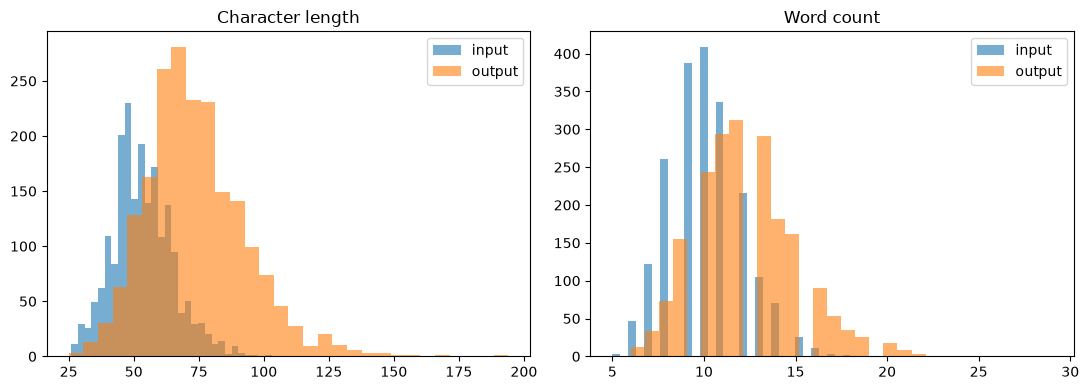

In [3]:
df["input_chars"] = df["input"].str.len()
df["output_chars"] = df["output"].str.len()
df["input_words"] = df["input"].str.split().str.len()
df["output_words"] = df["output"].str.split().str.len()

display(df[["input_chars", "output_chars", "input_words", "output_words"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["input_chars"], bins=30, alpha=0.6, label="input")
axes[0].hist(df["output_chars"], bins=30, alpha=0.6, label="output")
axes[0].set_title("Character length")
axes[0].legend()

axes[1].hist(df["input_words"], bins=30, alpha=0.6, label="input")
axes[1].hist(df["output_words"], bins=30, alpha=0.6, label="output")
axes[1].set_title("Word count")
axes[1].legend()
plt.tight_layout()
plt.show()

## `[pause]` tag coverage

How many pause tags per output, and what fraction of records have none (a normalization the model may be skipping).

pause_count
0      118
1     1012
2      507
3      185
4       95
5       46
6       11
7        8
8        7
9        5
10       2
11       1
14       1
Name: count, dtype: int64

records with zero [pause] tags: 118 (5.9%)


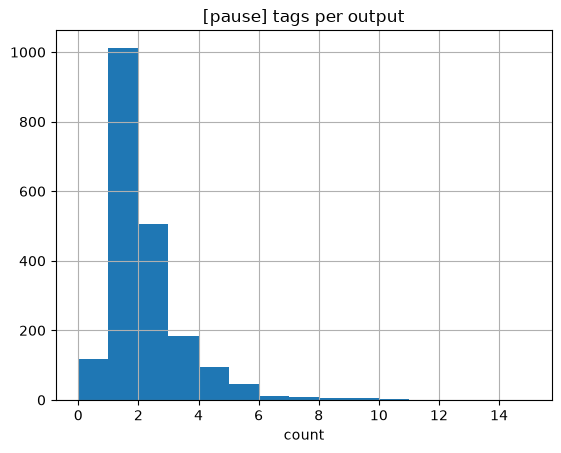

In [4]:
df["pause_count"] = df["output"].str.count(r"\[pause\]")
print(df["pause_count"].value_counts().sort_index())
print("\nrecords with zero [pause] tags:", (df["pause_count"] == 0).sum(),
      f"({(df['pause_count'] == 0).mean():.1%})")

df["pause_count"].hist(bins=range(0, df["pause_count"].max() + 2))
plt.title("[pause] tags per output")
plt.xlabel("count")
plt.show()

## Sentence type mix

Approximate mood from final punctuation: `?` question, `!` exclamation/command, `.`/none statement.

sentence_type
statement      1361
question        383
exclamation     254
Name: count, dtype: int64


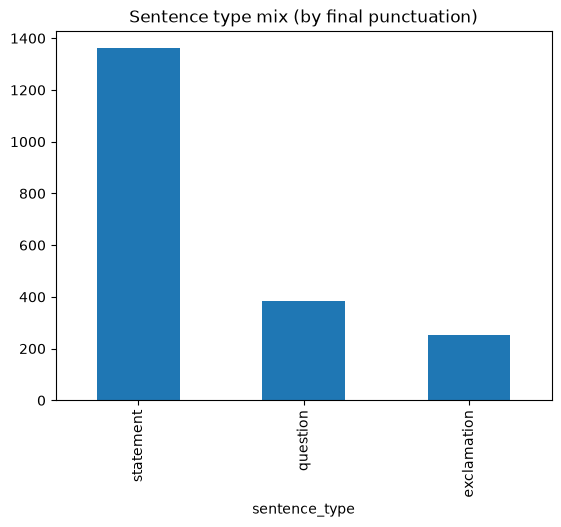

In [5]:
def sentence_type(text):
    text = text.strip()
    if text.endswith("?"):
        return "question"
    if text.endswith("!"):
        return "exclamation"
    return "statement"

df["sentence_type"] = df["input"].apply(sentence_type)
counts = df["sentence_type"].value_counts()
print(counts)
counts.plot.bar()
plt.title("Sentence type mix (by final punctuation)")
plt.show()

## English loanword / Latin-script coverage

Fraction of `input` sentences containing Latin characters (English loanwords, units like `km`/`GB`, `PM`, etc.), and whether they got transliterated out of `output` as intended (rule 3 in the normalization prompt).

In [6]:
latin_re = re.compile(r"[A-Za-z]")

df["input_has_latin"] = df["input"].str.contains(latin_re)
# Strip the [pause] tag itself before checking — its ASCII letters aren't leaked English.
df["output_has_latin"] = df["output"].str.replace(r"\[pause\]", "", regex=True).str.contains(latin_re)

print("inputs with Latin chars:", df["input_has_latin"].sum(), f"({df['input_has_latin'].mean():.1%})")
print("outputs still with Latin chars (excluding [pause] tags):", df["output_has_latin"].sum(), f"({df['output_has_latin'].mean():.1%})")

# Records where English survived into the normalized output (possible normalization misses)
leaked = df[df["input_has_latin"] & df["output_has_latin"]]
print(f"\n{len(leaked)} candidate leaks (Latin chars in both input and output):")
leaked[["input", "output"]].head(10)

inputs with Latin chars: 1930 (96.6%)
outputs still with Latin chars (excluding [pause] tags): 4 (0.2%)

4 candidate leaks (Latin chars in both input and output):


,input,output
79,"या dress वर 20% off आहे, price फक्त ₹९९९.","या ड्रेस वर [pause] वीस टक्के ऑफ आहे, [pause] ..."
278,"आपण जर ३ PM ला निघालो, तर Traffic मध्ये न अडकत...","आपण जर तीन वाजता दुपari निघालो, [pause] तर ट्र..."
345,Train number १२१२४ आज ३ तास late धावत आहे.,ट्रेन नंबर बारा हजार एकस्र चौviस [pause] आज ती...
1131,"अरे बापरे, आज तापमान थेट ४२.५°C पर्यंत पोहोचले...","अरे बापरे, [pause] आज तापमान थेट $\text{ब्याऐं..."


## Outliers

Shortest/longest inputs — useful for spotting truncated generations or degenerate one-word sentences.

In [7]:
print("Shortest inputs:")
display(df.nsmallest(5, "input_words")[["input", "output"]])

print("\nLongest inputs:")
display(df.nlargest(5, "input_words")[["input", "output"]])

Shortest inputs:


,input,output
831,झाडाला पाणी घालण्याचे विसरू नकोस!,झाडाला पाणी घालण्याचे विसरू नकोस! [pause]
881,"अरे यार, माझा Ticket हरवला!","अरे यार, [pause] माझा तिकीट हरवला!"
1597,काय सांगता! match आपण जिंकलो?,काय सांगता! [pause] मॅच आपण जिंकलो?
47,मी 1st class मध्ये pass झालो.,मी [pause] पहिला क्लास मध्ये [pause] पास झालो.
52,आज temperature ४२.५ degree Celsius पोहोचले.,आज [pause] टेंपरेचर [pause] बेचाळीस पूर्णांक प...



Longest inputs:


,input,output
76,मला एका Urgent Call साठी SIM Card मध्ये किमान ...,मला एका अर्जंट कॉल साठी [pause] सिम कार्ड मध्य...
354,"मी काल Doctor कडे गेलो होतो, त्यांनी मला Daily...","मी काल [pause] डॉक्टर कडे गेलो होतो, [pause] त..."
141,काल Match मध्ये Rohit Sharma ने 95 Runs काढले ...,काल मॅच मध्ये [pause] रोहित शर्मा ने पंच्याण्ण...
367,"त्यांनी नवीन Flat घेतला आहे, ज्याचा Area जवळपा...","त्यांनी नवीन फ्लॅट घेतला आहे, [pause] ज्याचा ए..."
1186,"अरे यार, माझा Train चा Ticket 3:45 PM चा आहे आ...","अरे यार, [pause] माझा ट्रेनचा तिकीट [pause] ती..."
